# Improved Qwen2.5-Coder-7B StackOverflow Fine-Tuning Notebook

This version applies the requested improvements:

- Uses **50,000 training samples**.
- Runs for **one full epoch**.
- Removes the `MAX_STEPS = 1200` cap by setting `MAX_STEPS = -1`.
- Increases `MAX_SEQ_LENGTH` from `512` to `1024` to reduce truncation.
- Increases LoRA capacity from `r=16, alpha=32` to `r=32, alpha=64`.
- Uses response-only loss masking so training focuses on the assistant answer instead of the full prompt.
- Keeps one learning rate only: `LEARNING_RATE = 2e-4`.

Base project: Qwen2.5-Coder-7B-Instruct fine-tuning on EMR-preprocessed StackOverflow Python Q&A.


---
## Section 0 — Configuration
Edit this cell first. Everything else reads from these variables.

This notebook supports two base-model loading modes:

1. **Use the S3 copy** you already uploaded: `s3://25jdvr-chatbot-bucket/model/qwen2.5-coder-base/`
2. **Use Hugging Face directly**: `Qwen/Qwen2.5-Coder-7B-Instruct`

For the project report, using the S3 copy is better because it shows your model artefacts are centralized in AWS.


In [1]:
# =========================
# Project paths
# =========================
S3_BUCKET       = "25jdvr-chatbot-bucket"
AWS_REGION      = "us-east-1"

# EMR preprocessing outputs
S3_TRAIN_PATH   = f"s3://{S3_BUCKET}/processed/train/"
S3_VAL_PATH     = f"s3://{S3_BUCKET}/processed/val/"

# Base model already uploaded to S3
S3_BASE_MODEL   = f"s3://{S3_BUCKET}/model/qwen2.5-coder-base/"

# Fine-tuned outputs
S3_OUTPUT_ROOT  = f"s3://{S3_BUCKET}/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/"
S3_ADAPTER_OUT  = f"{S3_OUTPUT_ROOT}adapter/"
S3_MERGED_OUT   = f"{S3_OUTPUT_ROOT}merged-hf/"
S3_GGUF_OUT     = f"{S3_OUTPUT_ROOT}gguf/"

# =========================
# Local paths inside notebook runtime / Docker container
# =========================
LOCAL_DATA_DIR         = "/workspace/data"
LOCAL_BASE_MODEL_DIR   = "/workspace/qwen2.5-coder-7b-base"
LOCAL_ADAPTER_DIR      = "/workspace/qwen2.5-coder-7b-adapter-improved-50k-1epoch"
LOCAL_MERGED_MODEL_DIR = "/workspace/qwen2.5-coder-7b-merged-hf-improved-50k-1epoch"
LOCAL_GGUF_DIR         = "/workspace/qwen2.5-coder-7b-gguf-improved-50k-1epoch"

# Set True to load model from S3 local download; False to load from Hugging Face.
USE_S3_BASE_MODEL = True
HF_BASE_MODEL     = "Qwen/Qwen2.5-Coder-7B-Instruct"
BASE_MODEL        = LOCAL_BASE_MODEL_DIR if USE_S3_BASE_MODEL else HF_BASE_MODEL

# =========================
# Improved LoRA / QLoRA settings for stronger domain adaptation
# =========================
LORA_RANK    = 32
LORA_ALPHA   = 64
LORA_DROPOUT = 0.05
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]

# =========================
# Training settings
# =========================
MAX_SEQ_LENGTH  = 1024       # increased from 512 to preserve more StackOverflow/code context
BATCH_SIZE      = 1          # safer for 7B on limited GPU memory
GRAD_ACCUM      = 16         # effective batch = 16
LEARNING_RATE   = 2e-4       # single LR setting, as requested; no LR sweep
NUM_EPOCHS      = 1          # exactly one full epoch
WARMUP_RATIO    = 0.05
WEIGHT_DECAY    = 0.01
MAX_TRAIN_ROWS  = 50_000     # requested training sample count
MAX_VAL_ROWS    = 1_000
MAX_STEPS       = 1500        # important: disables step cap so NUM_EPOCHS controls training
RANDOM_SEED     = 42
LOG_STEPS       = 25
SAVE_STEPS      = 100

# Optional extra filtering if these columns exist in your EMR output
MIN_ANSWER_LEN   = 300
MIN_ANSWER_SCORE = 4

SYSTEM_PROMPT = (
    "You are a helpful Python programming assistant. "
    "Answer StackOverflow-style questions clearly, explain the fix, "
    "and include working code examples when useful."
)

print("Configuration loaded")
print(f"  Base model mode : {'S3 local copy' if USE_S3_BASE_MODEL else 'Hugging Face'}")
print(f"  Base model      : {BASE_MODEL}")
print(f"  S3 train path   : {S3_TRAIN_PATH}")
print(f"  S3 val path     : {S3_VAL_PATH}")
print(f"  Output root     : {S3_OUTPUT_ROOT}")
print(f"  LoRA r/alpha    : {LORA_RANK}/{LORA_ALPHA}")
print(f"  Effective batch : {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Max seq length  : {MAX_SEQ_LENGTH}")
print(f"  Train rows cap  : {MAX_TRAIN_ROWS:,}")
print(f"  Epochs          : {NUM_EPOCHS}")
print(f"  Max steps       : {MAX_STEPS} (disabled; full epoch training)")


Configuration loaded
  Base model mode : S3 local copy
  Base model      : /workspace/qwen2.5-coder-7b-base
  S3 train path   : s3://25jdvr-chatbot-bucket/processed/train/
  S3 val path     : s3://25jdvr-chatbot-bucket/processed/val/
  Output root     : s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/
  LoRA r/alpha    : 32/64
  Effective batch : 1 x 16 = 16
  Max seq length  : 1024
  Train rows cap  : 50,000
  Epochs          : 1
  Max steps       : 1500 (disabled; full epoch training)


---
## Section 1 — Install Dependencies

Skip this cell if you are using the `unsloth/unsloth` Docker image. That image already includes CUDA, PyTorch, Unsloth, TRL, PEFT, bitsandbytes, and common training dependencies.

Run this cell only in a clean Colab/runtime where Unsloth is not installed.


In [2]:
# SKIP in unsloth/unsloth Docker unless packages are missing.
import sys, subprocess, os

IN_DOCKER = False
try:
    with open("/proc/1/cgroup") as f:
        IN_DOCKER = "docker" in f.read() or "containerd" in f.read()
except Exception:
    pass

if IN_DOCKER:
    print("Docker/container detected. If you are using unsloth/unsloth, dependencies should already be installed.")
else:
    print("Installing dependencies for a non-Docker runtime...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-U", "pip"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "unsloth", "boto3", "pyarrow", "datasets", "matplotlib"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "--no-deps", "trl", "peft", "accelerate", "bitsandbytes"], check=True)

print("Dependency cell finished")


Installing dependencies for a non-Docker runtime...
Dependency cell finished


---
## Section 2 — Imports and GPU Check


In [3]:
import os
import math
import json
import shutil
import logging
import subprocess
from datetime import datetime
from pathlib import Path

import boto3
import pyarrow.dataset as ds
import torch
from datasets import Dataset
from unsloth import FastLanguageModel
from unsloth.chat_templates import train_on_responses_only
from trl import SFTTrainer, SFTConfig

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger("qwen25-coder-7b-finetune-improved")

print("Imports OK")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
ERROR 05-04 08:53:59 [gpt_oss_triton_kernels_moe.py:34] Failed to import Triton kernels. Please make sure your triton version is compatible. Error: No module named 'triton_kernels.routing'
🦥 Unsloth Zoo will now patch everything to make training faster!
Imports OK


In [4]:
if not torch.cuda.is_available():
    raise RuntimeError(
        "No GPU was detected. For Qwen2.5-Coder-7B QLoRA, run on a CUDA GPU. "
        "If using Docker, launch with: docker run --gpus all ..."
    )

gpu_name = torch.cuda.get_device_name(0)
gpu_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
bf16_ok  = torch.cuda.is_bf16_supported()
USE_BF16 = bf16_ok
USE_FP16 = not bf16_ok

print(f"GPU           : {gpu_name}")
print(f"VRAM          : {gpu_vram:.1f} GB")
print(f"BF16 support  : {bf16_ok}")
print(f"Precision     : {'bf16' if USE_BF16 else 'fp16'}")
print(f"PyTorch       : {torch.__version__}")

if gpu_vram < 14:
    print("WARNING: VRAM is low for a 7B model. Consider MAX_SEQ_LENGTH=512 if 1024 causes OOM.")
elif gpu_vram < 20 and MAX_SEQ_LENGTH >= 1024:
    print("NOTE: MAX_SEQ_LENGTH=1024 may require careful memory management on smaller GPUs.")


GPU           : NVIDIA RTX 2000 Ada Generation
VRAM          : 17.2 GB
BF16 support  : True
Precision     : bf16
PyTorch       : 2.10.0+cu128
NOTE: MAX_SEQ_LENGTH=1024 may require careful memory management on smaller GPUs.


---
## Section 3 — AWS Credentials and S3 Access

The notebook reads AWS credentials from environment variables first. In Docker, pass them at launch time:

```bash
docker run --gpus all -it -p 8888:8888 \
  -v ~/fine-tuning:/workspace \
  -e AWS_ACCESS_KEY_ID=YOUR_KEY \
  -e AWS_SECRET_ACCESS_KEY=YOUR_SECRET \
  -e AWS_DEFAULT_REGION=us-east-1 \
  unsloth/unsloth \
  jupyter notebook --ip=0.0.0.0 --no-browser --allow-root
```


In [5]:
import getpass

aws_key    = os.environ.get("AWS_ACCESS_KEY_ID", "")
aws_secret = os.environ.get("AWS_SECRET_ACCESS_KEY", "")
aws_region = os.environ.get("AWS_DEFAULT_REGION", AWS_REGION)

if not aws_key or not aws_secret:
    print("AWS credentials were not found in environment variables.")
    aws_key    = getpass.getpass("AWS_ACCESS_KEY_ID: ")
    aws_secret = getpass.getpass("AWS_SECRET_ACCESS_KEY: ")

os.environ["AWS_ACCESS_KEY_ID"]     = aws_key
os.environ["AWS_SECRET_ACCESS_KEY"] = aws_secret
os.environ["AWS_DEFAULT_REGION"]    = aws_region

s3 = boto3.client("s3", region_name=aws_region)
sts = boto3.client("sts", region_name=aws_region)
print("AWS identity:", sts.get_caller_identity()["Arn"])
print("AWS region  :", aws_region)


AWS credentials were not found in environment variables.


AWS_ACCESS_KEY_ID:  ········
AWS_SECRET_ACCESS_KEY:  ········


AWS identity: arn:aws:iam::507519853509:user/Cloud-N3
AWS region  : us-east-1


---
## Section 4 — Download the Base Model from S3, if Enabled

You already downloaded `Qwen/Qwen2.5-Coder-7B-Instruct` and uploaded it to:

```text
s3://25jdvr-chatbot-bucket/model/qwen2.5-coder-base/
```

This cell downloads that S3 folder into the notebook runtime so Unsloth can load the model from a local path. If `USE_S3_BASE_MODEL = False`, this cell is skipped and the notebook loads the model from Hugging Face instead.


In [6]:
def parse_s3_uri(uri: str):
    assert uri.startswith("s3://"), f"Not an S3 URI: {uri}"
    no_scheme = uri.replace("s3://", "", 1)
    bucket = no_scheme.split("/", 1)[0]
    prefix = no_scheme.split("/", 1)[1] if "/" in no_scheme else ""
    return bucket, prefix.rstrip("/") + "/"


def download_s3_prefix(s3_uri: str, local_dir: str):
    bucket, prefix = parse_s3_uri(s3_uri)
    os.makedirs(local_dir, exist_ok=True)
    paginator = s3.get_paginator("list_objects_v2")
    total = 0
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            key = obj["Key"]
            if key.endswith("/"):
                continue
            rel = key[len(prefix):]
            local_path = os.path.join(local_dir, rel)
            os.makedirs(os.path.dirname(local_path), exist_ok=True)
            if os.path.exists(local_path) and os.path.getsize(local_path) == obj["Size"]:
                print(f"Cached: {rel}")
            else:
                print(f"Downloading: {rel} ({obj['Size']/1e9:.2f} GB)")
                s3.download_file(bucket, key, local_path)
            total += 1
    print(f"Downloaded/verified {total} file(s) from {s3_uri}")

if USE_S3_BASE_MODEL:
    download_s3_prefix(S3_BASE_MODEL, LOCAL_BASE_MODEL_DIR)
    print("\nLocal base model files:")
    for p in sorted(Path(LOCAL_BASE_MODEL_DIR).iterdir()):
        if p.is_file():
            print(f"  {p.name:35s} {p.stat().st_size/1e6:10.1f} MB")
else:
    print("USE_S3_BASE_MODEL is False, so the model will be loaded from Hugging Face:", HF_BASE_MODEL)


Cached: .cache/huggingface/.gitignore
Cached: .cache/huggingface/CACHEDIR.TAG
Cached: .cache/huggingface/download/.gitattributes.metadata
Cached: .cache/huggingface/download/LICENSE.metadata
Cached: .cache/huggingface/download/README.md.metadata
Cached: .cache/huggingface/download/config.json.metadata
Cached: .cache/huggingface/download/generation_config.json.metadata
Cached: .cache/huggingface/download/merges.txt.metadata
Cached: .cache/huggingface/download/model-00001-of-00004.safetensors.metadata
Cached: .cache/huggingface/download/model-00002-of-00004.safetensors.metadata
Cached: .cache/huggingface/download/model-00003-of-00004.safetensors.metadata
Cached: .cache/huggingface/download/model-00004-of-00004.safetensors.metadata
Cached: .cache/huggingface/download/model.safetensors.index.json.metadata
Cached: .cache/huggingface/download/tokenizer.json.metadata
Cached: .cache/huggingface/download/tokenizer_config.json.metadata
Cached: .cache/huggingface/download/vocab.json.metadata
Cach

---
## Section 5 — Load Preprocessed StackOverflow Data from S3

This reads the Parquet files written by the EMR PySpark preprocessing step. The training column must be `text`, already formatted as Qwen ChatML:

```text
<|im_start|>system
...
<|im_end|>
<|im_start|>user
...
<|im_end|>
<|im_start|>assistant
...
<|im_end|>
```


In [7]:
def load_parquet_from_s3(s3_path: str, max_rows: int, label: str) -> Dataset:
    bucket, prefix = parse_s3_uri(s3_path)
    paginator = s3.get_paginator("list_objects_v2")
    keys = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        keys.extend([obj["Key"] for obj in page.get("Contents", []) if obj["Key"].endswith(".parquet")])

    if not keys:
        raise FileNotFoundError(f"No parquet files found at {s3_path}. Check the EMR output path.")

    print(f"Found {len(keys)} parquet file(s) for {label}")
    os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
    local_files = []

    for key in keys:
        fname = key.split("/")[-1]
        local_path = os.path.join(LOCAL_DATA_DIR, f"{label}_{fname}")
        if not os.path.exists(local_path):
            size_mb = s3.head_object(Bucket=bucket, Key=key)["ContentLength"] / 1e6
            print(f"Downloading {fname} ({size_mb:.1f} MB)")
            s3.download_file(bucket, key, local_path)
        else:
            print(f"Cached: {fname}")
        local_files.append(local_path)

    arrow_ds = ds.dataset(local_files, format="parquet")
    table = arrow_ds.to_table()
    df = table.to_pandas()

    if "text" not in df.columns:
        raise ValueError(f"Expected a 'text' column in {label} parquet files. Columns found: {list(df.columns)}")

    df = df.dropna(subset=["text"])
    df = df[df["text"].astype(str).str.len() > 50].copy()

    # Optional quality filter only if these columns exist.
    if "a_length" in df.columns and "a_score" in df.columns:
        before = len(df)
        df = df[(df["a_length"] >= MIN_ANSWER_LEN) & (df["a_score"] >= MIN_ANSWER_SCORE)].copy()
        removed = before - len(df)
        print(f"Quality filter removed {removed:,} rows from {label}")
    else:
        print(f"No a_length/a_score columns in {label}; using the EMR-preprocessed rows as-is.")

    df = df[["text"]].reset_index(drop=True)
    if len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=RANDOM_SEED).reset_index(drop=True)

    print(f"{label}: {len(df):,} rows ready")
    return Dataset.from_pandas(df)

train_dataset = load_parquet_from_s3(S3_TRAIN_PATH, MAX_TRAIN_ROWS, "train")
val_dataset   = load_parquet_from_s3(S3_VAL_PATH, MAX_VAL_ROWS, "val")

print("\nDataset summary")
print(f"  Train: {len(train_dataset):,}")
print(f"  Val  : {len(val_dataset):,}")


Found 20 parquet file(s) for train
Cached: part-00000-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00001-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00002-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00003-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00004-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00005-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00006-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00007-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00008-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00009-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00010-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00011-2c5a8a10-cfcd-4890-a841-5ad20eecccea-c000.snappy.parquet
Cached: part-00012-2c5a8a10-cfcd-4890-a841-5ad20eeccc

In [8]:
sample = train_dataset[0]["text"]
print("=" * 80)
print("TRAINING SAMPLE")
print("=" * 80)
print(sample[:1500])

required_tags = ["<|im_start|>system", "<|im_start|>user", "<|im_start|>assistant", "<|im_end|>"]
for tag in required_tags:
    assert tag in sample, f"Missing ChatML tag: {tag}"
print("\nChatML format verified")


TRAINING SAMPLE
<|im_start|>system
You are a helpful Python programming assistant. Provide clear, accurate answers with working code examples.<|im_end|>
<|im_start|>user
Seaborn, change font size of the colorbar<|im_end|>
<|im_start|>assistant
You can change the font scale with the seaborn.set() method setting the font_scale param to the scale you want, see more in seaborn documentation .

 For example, your plot with scale 3:

 import seaborn as sns
import matplotlib.pyplot as plt
from numpy import arange
# here set the scale by 3
sns.set(font_scale=3)
x = arange(25).reshape(5, 5)
cmap = sns.diverging_palette(220, 20, sep=20, as_cmap=True)
ax = sns.heatmap(x, cmap=cmap)
plt.show()<|im_end|>

ChatML format verified


---
## Section 6 — Load Qwen2.5-Coder-7B in 4-bit and Attach LoRA Adapters

The base model stays frozen. Only LoRA adapter weights are updated, which is why this can run on limited GPU memory.


In [9]:
print(f"Loading base model: {BASE_MODEL}")
print(f"Max sequence length: {MAX_SEQ_LENGTH}")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,
    load_in_4bit   = True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

used_gb  = torch.cuda.memory_allocated() / 1e9
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"Model loaded. VRAM used: {used_gb:.2f} GB / {vram_gb:.2f} GB")


Loading base model: /workspace/qwen2.5-coder-7b-base
Max sequence length: 1024
==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.1. vLLM: 0.16.1.dev0+g89a77b108.d20260417.cu128.
   \\   /|    NVIDIA RTX 2000 Ada Generation. Num GPUs = 1. Max memory: 15.996 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded. VRAM used: 5.59 GB / 17.18 GB


In [10]:
model = FastLanguageModel.get_peft_model(
    model,
    r                          = LORA_RANK,
    target_modules             = LORA_TARGET_MODULES,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = RANDOM_SEED,
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print("LoRA adapters attached")
print(f"  Trainable parameters : {trainable:,} ({100 * trainable / total:.2f}%)")
print(f"  Total parameters     : {total:,}")
print(f"  VRAM after adapters  : {torch.cuda.memory_allocated()/1e9:.2f} GB")


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.4.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA adapters attached
  Trainable parameters : 80,740,352 (1.82%)
  Total parameters     : 4,433,712,640
  VRAM after adapters  : 5.91 GB


---
## Section 7 — Capture Base Model Responses Before Training

These responses are used in the report for the required base-vs-fine-tuned comparison.


In [11]:
BASE_TEST_PROMPTS = [
    "How do I remove duplicates from a Python list while preserving order?",
    "What is the difference between == and is in Python?",
    "How do I handle a KeyError when accessing a Python dictionary?",
]

def build_prompt(question: str) -> str:
    return (
        f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n"
        f"<|im_start|>user\n{question}<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


def generate_answer(mdl, tok, question: str, max_new_tokens: int = 300) -> str:
    prompt = build_prompt(question)
    inputs = tok(prompt, return_tensors="pt").to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(
            **inputs,
            max_new_tokens     = max_new_tokens,
            temperature        = 0.7,
            top_p              = 0.9,
            do_sample          = True,
            pad_token_id       = tok.eos_token_id,
            repetition_penalty = 1.1,
        )
    new_tokens = out[0][inputs["input_ids"].shape[1]:]
    return tok.decode(new_tokens, skip_special_tokens=True).strip()

FastLanguageModel.for_inference(model)
base_responses = {}

print("BASE MODEL RESPONSES")
print("=" * 80)
for q in BASE_TEST_PROMPTS:
    answer = generate_answer(model, tokenizer, q)
    base_responses[q] = answer
    print(f"\nQUESTION: {q}")
    print("BASE MODEL:")
    print(answer)

FastLanguageModel.for_training(model)
print("\nBase responses saved. Training mode restored.")


BASE MODEL RESPONSES

QUESTION: How do I remove duplicates from a Python list while preserving order?
BASE MODEL:
To remove duplicates from a Python list while preserving the original order of elements, you can use a combination of a loop and a set. Here's how you can achieve this:

1. **Using a Loop and Set**: This method involves iterating through the list and adding each element to a new list only if it hasn't been encountered before. The set is used to keep track of seen elements.

2. **Using List Comprehension with Set**: You can also use a list comprehension combined with a set to filter out duplicates efficiently.

Here’s an example using both methods:

### Method 1: Using a Loop and Set

```python
def remove_duplicates_preserve_order(my_list):
    seen = set()
    result = []
    for item in my_list:
        if item not in seen:
            seen.add(item)
            result.append(item)
    return result

# Example usage
original_list = [1, 2, 3, 2, 4, 3, 5]
unique_list = remov

---
## Section 8 — Token Length Check

This verifies how much truncation will happen at the improved `MAX_SEQ_LENGTH = 1024`.


In [12]:
print("Checking token lengths on up to 500 training samples...")
sample_size = min(500, len(train_dataset))
texts = [train_dataset[i]["text"] for i in range(sample_size)]
lengths = [tokenizer(t, return_tensors="pt")["input_ids"].shape[1] for t in texts]

avg_len = sum(lengths) / len(lengths)
p50 = sorted(lengths)[int(0.50 * len(lengths))]
p90 = sorted(lengths)[int(0.90 * len(lengths))]
p95 = sorted(lengths)[int(0.95 * len(lengths))]
max_len = max(lengths)
over_limit = sum(1 for x in lengths if x > MAX_SEQ_LENGTH)

print(f"Average tokens : {avg_len:.0f}")
print(f"P50 tokens     : {p50}")
print(f"P90 tokens     : {p90}")
print(f"P95 tokens     : {p95}")
print(f"Max tokens     : {max_len}")
print(f"Over limit     : {over_limit}/{sample_size} ({100 * over_limit / sample_size:.1f}%)")


Checking token lengths on up to 500 training samples...
Average tokens : 279
P50 tokens     : 222
P90 tokens     : 486
P95 tokens     : 609
Max tokens     : 1658
Over limit     : 5/500 (1.0%)


---
## Section 9 — Train

Hyperparameters for the improved run:

| Hyperparameter | Value | Reason |
|---|---:|---|
| `MAX_TRAIN_ROWS` | 50,000 | Requested training sample count |
| `NUM_EPOCHS` | 1 | One full epoch, as requested |
| `MAX_STEPS` | -1 | Disables step cap so training is controlled by epoch count |
| `MAX_SEQ_LENGTH` | 1024 | Preserves more code/error/answer context and reduces truncation |
| `BATCH_SIZE` | 1 | Safer for 7B on limited GPU memory |
| `GRAD_ACCUM` | 16 | Effective batch size = 16 |
| `LEARNING_RATE` | 2e-4 | Single learning rate setting, no LR experiment sweep |
| `LORA_RANK` | 32 | More adapter capacity than rank 16 |
| `LORA_ALPHA` | 64 | Standard scaling for rank 32 |
| `optim` | `adamw_8bit` | Lower optimizer memory |
| Response-only loss | Enabled | Optimizes the assistant answer instead of the full prompt |


In [13]:
steps_per_epoch = math.ceil(len(train_dataset) / (BATCH_SIZE * GRAD_ACCUM))
total_steps     = steps_per_epoch * NUM_EPOCHS
actual_steps    = total_steps if MAX_STEPS == -1 else min(total_steps, MAX_STEPS)

print("Training plan")
print(f"  Train samples    : {len(train_dataset):,}")
print(f"  Validation rows  : {len(val_dataset):,}")
print(f"  Effective batch  : {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE * GRAD_ACCUM}")
print(f"  Steps per epoch  : {steps_per_epoch:,}")
print(f"  Epochs           : {NUM_EPOCHS}")
print(f"  Max steps        : {MAX_STEPS} ({'disabled' if MAX_STEPS == -1 else 'enabled'})")
print(f"  Planned steps    : {actual_steps:,}")

training_args = SFTConfig(
    output_dir                  = LOCAL_ADAPTER_DIR,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    num_train_epochs            = NUM_EPOCHS,
    max_steps                   = MAX_STEPS,
    learning_rate               = LEARNING_RATE,
    lr_scheduler_type           = "cosine",
    warmup_ratio                = WARMUP_RATIO,
    weight_decay                = WEIGHT_DECAY,
    max_seq_length              = MAX_SEQ_LENGTH,
    fp16                        = USE_FP16,
    bf16                        = USE_BF16,
    optim                       = "adamw_8bit",
    gradient_checkpointing      = True,
    logging_steps               = LOG_STEPS,
    eval_strategy               = "steps",
    eval_steps                  = SAVE_STEPS,
    save_strategy               = "steps",
    save_steps                  = SAVE_STEPS,
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    dataset_text_field          = "text",
    seed                        = RANDOM_SEED,
    report_to                   = "none",
)

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    args          = training_args,
)

# Important improvement: train loss is applied only to assistant response tokens.
# This avoids spending loss on predicting the system prompt and user question.
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)

print("Trainer ready with response-only loss masking. Run the next cell to start training.")


Training plan
  Train samples    : 50,000
  Validation rows  : 1,000
  Effective batch  : 1 x 16 = 16
  Steps per epoch  : 3,125
  Epochs           : 1
  Max steps        : 1500 (enabled)
  Planned steps    : 1,500


Unsloth: Tokenizing ["text"] (num_proc=10):   0%|          | 0/50000 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=10):   0%|          | 0/1000 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


Map (num_proc=10):   0%|          | 0/50000 [00:00<?, ? examples/s]

Filter (num_proc=10):   0%|          | 0/50000 [00:00<?, ? examples/s]

Map (num_proc=10):   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter (num_proc=10):   0%|          | 0/1000 [00:00<?, ? examples/s]

Trainer ready with response-only loss masking. Run the next cell to start training.


In [14]:
print(f"Training started at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
train_start = datetime.now()
result = trainer.train()
duration = datetime.now() - train_start

print("\nTraining complete")
print(f"  Duration         : {str(duration).split('.')[0]}")
print(f"  Final train loss : {result.training_loss:.4f}")
print(f"  Steps run        : {result.global_step}")
print(f"  Peak VRAM used   : {torch.cuda.max_memory_allocated()/1e9:.2f} GB")


Training started at 2026-05-04 08:55:44


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 50,000 | Num Epochs = 1 | Total steps = 1,500
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 80,740,352 of 7,696,356,864 (1.05% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,1.535300,1.620555
200,1.465400,1.612288
300,1.572300,1.609541
400,1.570700,1.605230
500,1.576200,1.602500
600,1.509600,1.600121
700,1.548300,1.597669
800,1.495200,1.594859
900,1.499800,1.593622
1000,1.441600,1.590804



Training complete
  Duration         : 6:29:43
  Final train loss : 1.5251
  Steps run        : 1500
  Peak VRAM used   : 7.28 GB


---
## Section 10 — Loss Curve and Base vs Fine-Tuned Comparison

Use the generated `loss_curve_qwen2.5_coder_7b.png` and the printed comparisons in Section 5 of the report.


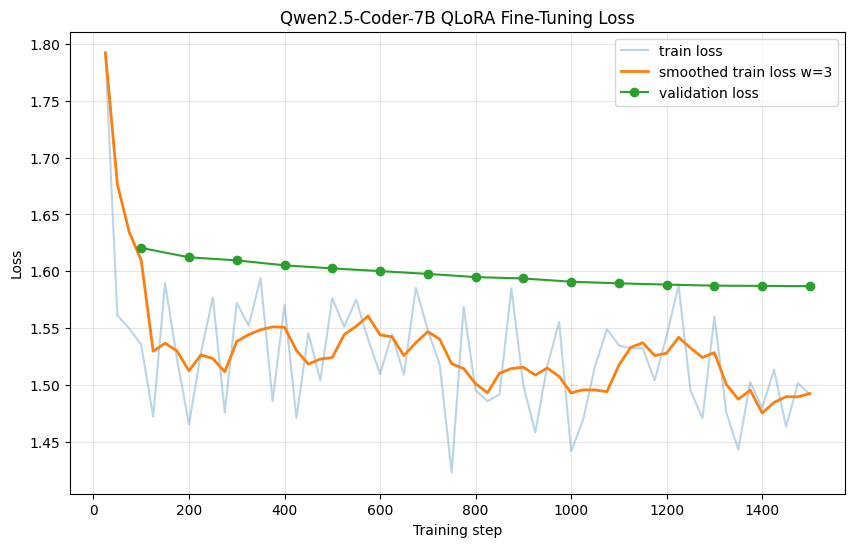

Loss curve saved to: /workspace/loss_curve_qwen2.5_coder_7b.png

BASE MODEL vs FINE-TUNED MODEL

QUESTION: How do I remove duplicates from a Python list while preserving order?

BASE MODEL RESPONSE:
To remove duplicates from a Python list while preserving the original order of elements, you can use a combination of a loop and a set. Here's how you can achieve this:

1. **Using a Loop and Set**: This method involves iterating through the list and adding each element to a new list only if it hasn't been encountered before. The set is used to keep track of seen elements.

2. **Using List Comprehension with Set**: You can also use a list comprehension combined with a set to filter out duplicates efficiently.

Here’s an example using both methods:

### Method 1: Using a Loop and Set

```python
def remove_duplicates_preserve_order(my_list):
    seen = set()
    result = []
    for item in my_list:
        if item not in seen:
            seen.add(item)
            result.append(item)
    ret

In [15]:
import matplotlib.pyplot as plt

train_logs = [x for x in trainer.state.log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in trainer.state.log_history if "eval_loss" in x]

if not train_logs:
    print("No training logs found. Run the training cell first.")
else:
    steps = [x["step"] for x in train_logs]
    losses = [x["loss"] for x in train_logs]
    window = max(1, len(losses) // 20)
    smoothed = [sum(losses[max(0, i-window):i+1]) / len(losses[max(0, i-window):i+1]) for i in range(len(losses))]

    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, alpha=0.3, label="train loss")
    plt.plot(steps, smoothed, linewidth=2, label=f"smoothed train loss w={window}")
    if eval_logs:
        plt.plot([x["step"] for x in eval_logs], [x["eval_loss"] for x in eval_logs], marker="o", label="validation loss")
    plt.title("Qwen2.5-Coder-7B QLoRA Fine-Tuning Loss")
    plt.xlabel("Training step")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    out_path = "/workspace/loss_curve_qwen2.5_coder_7b.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Loss curve saved to: {out_path}")

print("\nBASE MODEL vs FINE-TUNED MODEL")
print("=" * 80)
FastLanguageModel.for_inference(model)

for q in BASE_TEST_PROMPTS:
    ft_answer = generate_answer(model, tokenizer, q)
    print(f"\nQUESTION: {q}")
    print("\nBASE MODEL RESPONSE:")
    print(base_responses.get(q, "[base response not captured]"))
    print("\nFINE-TUNED MODEL RESPONSE:")
    print(ft_answer)
    print("-" * 80)


---
## Section 11 — Save LoRA Adapter and Upload to S3

This saves the small LoRA adapter, not the full merged model.


In [16]:
os.makedirs(LOCAL_ADAPTER_DIR, exist_ok=True)
model.save_pretrained(LOCAL_ADAPTER_DIR)
tokenizer.save_pretrained(LOCAL_ADAPTER_DIR)
print(f"Adapter saved locally: {LOCAL_ADAPTER_DIR}")

adapter_bucket, adapter_prefix = parse_s3_uri(S3_ADAPTER_OUT)
for root, _, files in os.walk(LOCAL_ADAPTER_DIR):
    for fname in files:
        local_file = os.path.join(root, fname)
        rel = os.path.relpath(local_file, LOCAL_ADAPTER_DIR)
        key = adapter_prefix + rel.replace(os.sep, "/")
        s3.upload_file(local_file, adapter_bucket, key)
        print(f"Uploaded: s3://{adapter_bucket}/{key}")

print("Adapter upload complete")


Adapter saved locally: /workspace/qwen2.5-coder-7b-adapter-improved-50k-1epoch
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/merges.txt
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/added_tokens.json
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/chat_template.jinja
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/adapter_model.safetensors
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/tokenizer.json
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/adapter_config.json
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/tokenizer_config.json
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/speci

---
## Section 12 — Merge LoRA into the Base Model and Upload Hugging Face Format to S3

This creates a merged model folder that can later be converted to GGUF for Ollama.

For 7B, the merged model can be large. Make sure the runtime has enough disk space before running this section.


In [17]:
print("Disk space before merge:")
subprocess.run(["df", "-h", "/workspace"], check=False)

os.makedirs(LOCAL_MERGED_MODEL_DIR, exist_ok=True)

# Saves full merged model in 16-bit Hugging Face format.
# If you run out of disk, save adapter only and convert later on a larger machine.
model.save_pretrained_merged(
    LOCAL_MERGED_MODEL_DIR,
    tokenizer,
    save_method = "merged_16bit",
)

print(f"Merged model saved locally: {LOCAL_MERGED_MODEL_DIR}")
print("Files:")
for p in sorted(Path(LOCAL_MERGED_MODEL_DIR).iterdir()):
    if p.is_file():
        print(f"  {p.name:40s} {p.stat().st_size/1e9:8.2f} GB")


Disk space before merge:
Filesystem      Size  Used Avail Use% Mounted on
overlay        1007G  100G  856G  11% /
Detected local model directory: /workspace/qwen2.5-coder-7b-base
Found HuggingFace hub cache directory: /workspace/.cache/huggingface/hub


Unsloth: Preparing safetensor model files:  25%|██▌       | 1/4 [00:03<00:10,  3.47s/it]

Copied model-00004-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files:  50%|█████     | 2/4 [00:15<00:17,  8.78s/it]

Copied model-00003-of-00004.safetensors from local model directory


...

Copied model-00002-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████| 4/4 [00:49<00:00, 12.33s/it]


Copied model-00001-of-00004.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:44<00:00, 11.06s/it]


Unsloth: Merge process complete. Saved to `/workspace/qwen2.5-coder-7b-merged-hf-improved-50k-1epoch`
Merged model saved locally: /workspace/qwen2.5-coder-7b-merged-hf-improved-50k-1epoch
Files:
  added_tokens.json                            0.00 GB
  chat_template.jinja                          0.00 GB
  config.json                                  0.00 GB
  merges.txt                                   0.00 GB
  model-00001-of-00004.safetensors             4.88 GB
  model-00002-of-00004.safetensors             4.93 GB
  model-00003-of-00004.safetensors             4.33 GB
  model-00004-of-00004.safetensors             1.09 GB
  model.safetensors.index.json                 0.00 GB
  special_tokens_map.json                      0.00 GB
  tokenizer.json                               0.01 GB
  tokenizer_config.json                        0.00 GB
  vocab.json                                   0.00 GB


In [18]:
merged_bucket, merged_prefix = parse_s3_uri(S3_MERGED_OUT)
for root, _, files in os.walk(LOCAL_MERGED_MODEL_DIR):
    for fname in files:
        local_file = os.path.join(root, fname)
        rel = os.path.relpath(local_file, LOCAL_MERGED_MODEL_DIR)
        key = merged_prefix + rel.replace(os.sep, "/")
        s3.upload_file(local_file, merged_bucket, key)
        print(f"Uploaded: s3://{merged_bucket}/{key}")

print("Merged Hugging Face model upload complete")


Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/model.safetensors.index.json
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/merges.txt
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/added_tokens.json
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/chat_template.jinja
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/model-00004-of-00004.safetensors
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/model-00003-of-00004.safetensors
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/tokenizer.json
Uploaded: s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/config.json
Uploaded: s3://25jdvr-chatbot

---
## Section 13 — Export GGUF for Ollama and Upload to S3

Run this if you want to deploy with Ollama. The recommended quantization for EC2 testing is `q4_k_m`.

If this cell fails because the runtime lacks llama.cpp tooling, you can still use the merged Hugging Face model in `S3_MERGED_OUT` and convert it later on the EC2 deployment instance.


In [19]:
os.makedirs(LOCAL_GGUF_DIR, exist_ok=True)

try:
    model.save_pretrained_gguf(
        LOCAL_GGUF_DIR,
        tokenizer,
        quantization_method = "q4_k_m",
    )
    print(f"GGUF exported to: {LOCAL_GGUF_DIR}")
except Exception as e:
    print("GGUF export failed in this runtime.")
    print("Reason:", repr(e))
    print("You can still deploy by converting the merged HF model from S3 on EC2 later.")


Unsloth: Merging model weights to 16-bit format...
Detected local model directory: /workspace/qwen2.5-coder-7b-base
Found HuggingFace hub cache directory: /workspace/.cache/huggingface/hub


Unsloth: Preparing safetensor model files:  25%|██▌       | 1/4 [00:00<00:02,  1.34it/s]

Copied model-00004-of-00004.safetensors from local model directory


Unsloth: Preparing safetensor model files:  50%|█████     | 2/4 [00:05<00:06,  3.34s/it]

Copied model-00003-of-00004.safetensors from local model directory


...

Copied model-00001-of-00004.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|██████████| 4/4 [00:34<00:00,  8.69s/it]


Unsloth: Merge process complete. Saved to `/workspace/qwen2.5-coder-7b-gguf-improved-50k-1epoch`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF bf16 might take 3 minutes.
\        /    [2] Converting GGUF bf16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: llama.cpp found in the system. Skipping installation.
Unsloth: Preparing converter script...


[unsloth_zoo.llama_cpp|WARNING]Unsloth: Qwen2MoE num_experts patch target not found.


Unsloth: [1] Converting model into bf16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['/workspace/qwen2.5-coder-7b-gguf-improved-50k-1epoch_gguf/qwen2.5-coder-7b-base.BF16.gguf']
Unsloth: [2] Converting GGUF bf16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated files: ['/workspace/qwen2.5-coder-7b-gguf-improved-50k-1epoch_gguf/qwen2.5-coder-7b-base.Q4_K_M.gguf']
Unsloth: No Ollama template mapping found for model '/workspace/qwen2.5-coder-7b-base'. Skipping Ollama Modelfile
Unsloth: example usage for text only LLMs: /home/unsloth/.unsloth/llama.cpp/llama-cli --model /workspace/qwen2.5-coder-7b-gguf-improved-50k-1epoch_gguf/qwen2.5-coder-7b-base.Q4_K_M.gguf -p "why is the sky blue?"
GGUF exported to: /workspace/qwen2.5-coder-7b-gguf-improved-50k-1epoch


In [20]:
# Create Ollama Modelfile
modelfile_path = os.path.join(LOCAL_GGUF_DIR, "Modelfile")
modelfile_text = (
    "FROM ./model.gguf\n\n"
    "SYSTEM \"\"\"\n"
    f"{SYSTEM_PROMPT}\n"
    "\"\"\"\n\n"
    "PARAMETER temperature 0.7\n"
    "PARAMETER top_p 0.9\n"
    "PARAMETER top_k 40\n"
    "PARAMETER repeat_penalty 1.1\n"
    "PARAMETER num_ctx 2048\n"
)
with open(modelfile_path, "w", encoding="utf-8") as f:
    f.write(modelfile_text)
print(f"Modelfile written: {modelfile_path}")

# If Unsloth saved the GGUF with a different name, rename/copy the first .gguf to model.gguf for Ollama consistency.
gguf_files = list(Path(LOCAL_GGUF_DIR).glob("*.gguf"))
if gguf_files:
    target = Path(LOCAL_GGUF_DIR) / "model.gguf"
    if gguf_files[0].name != "model.gguf":
        shutil.copy2(gguf_files[0], target)
        print(f"Copied {gguf_files[0].name} -> model.gguf")
else:
    print("No GGUF file found. Skip S3 upload until GGUF export succeeds.")


Modelfile written: /workspace/qwen2.5-coder-7b-gguf-improved-50k-1epoch/Modelfile
No GGUF file found. Skip S3 upload until GGUF export succeeds.


In [21]:
gguf_bucket, gguf_prefix = parse_s3_uri(S3_GGUF_OUT)

if not list(Path(LOCAL_GGUF_DIR).glob("*.gguf")):
    print("No GGUF file exists, so nothing was uploaded.")
else:
    for root, _, files in os.walk(LOCAL_GGUF_DIR):
        for fname in files:
            local_file = os.path.join(root, fname)
            rel = os.path.relpath(local_file, LOCAL_GGUF_DIR)
            key = gguf_prefix + rel.replace(os.sep, "/")
            s3.upload_file(local_file, gguf_bucket, key)
            print(f"Uploaded: s3://{gguf_bucket}/{key}")
    print("GGUF upload complete")


No GGUF file exists, so nothing was uploaded.


---
## Section 14 — S3 Verification Commands for the Report

Run these in a terminal or notebook shell to capture screenshots for the report.


In [22]:
print("Adapter files:")
print(f"aws s3 ls {S3_ADAPTER_OUT} --recursive --human-readable --summarize --region {AWS_REGION}")
print("\nMerged Hugging Face files:")
print(f"aws s3 ls {S3_MERGED_OUT} --recursive --human-readable --summarize --region {AWS_REGION}")
print("\nGGUF deployment files:")
print(f"aws s3 ls {S3_GGUF_OUT} --recursive --human-readable --summarize --region {AWS_REGION}")


Adapter files:
aws s3 ls s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/adapter/ --recursive --human-readable --summarize --region us-east-1

Merged Hugging Face files:
aws s3 ls s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/merged-hf/ --recursive --human-readable --summarize --region us-east-1

GGUF deployment files:
aws s3 ls s3://25jdvr-chatbot-bucket/model/finetuned-qwen2.5-coder-7b-improved-50k-1epoch/gguf/ --recursive --human-readable --summarize --region us-east-1
